In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor


In [2]:
cols = ['unit', 'cycle'] \
     + [f'op_setting_{i}' for i in range(1, 4)] \
     + [f'sensor_{i}' for i in range(1, 22)]

df = pd.read_csv('../data/CMaps/train_FD001.txt',
                 sep=r'\s+', header=None, names=cols)

In [3]:
df['RUL']=df.groupby('unit')['cycle'].transform('max') - df['cycle']
df['RUL_capped']= df['RUL'].clip(upper=125)
engine96 = df[df['unit'] == 96]

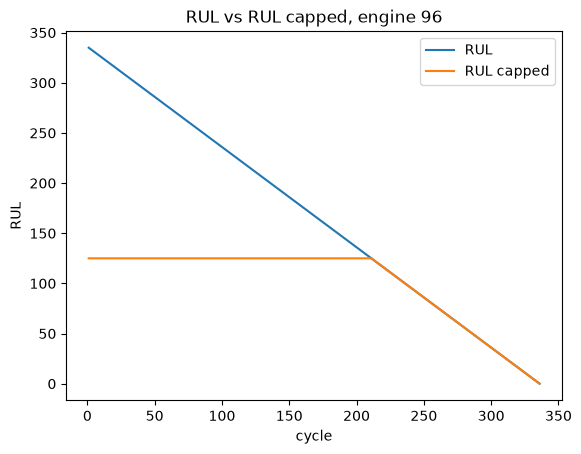

In [4]:
engine96 = df[df['unit'] == 96]
plt.plot(engine96['cycle'], engine96['RUL'], label='RUL')
plt.plot(engine96['cycle'], engine96['RUL_capped'], label='RUL capped')
plt.xlabel('cycle')
plt.ylabel('RUL')
plt.title('RUL vs RUL capped, engine 96')
plt.legend()
plt.savefig('../figures/rul_capping.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
sensor_cols = cols[5:]           

early = df.groupby('unit').head(10)[sensor_cols].mean()
late  = df.groupby('unit').tail(10)[sensor_cols].mean()

trend = late - early
up = trend[trend > 0]
down = trend [ trend <0 ]
nochange = trend [trend == 0]

dead = list(nochange.index)
features = [s for s in sensor_cols if s not in dead]
print(features)
print(len(features))

['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
15


In [6]:
test_df = pd.read_csv('../data/CMaps/test_FD001.txt',
                 sep=r'\s+', header=None, names=cols)
rul_df = pd.read_csv('../data/CMaps/RUL_FD001.txt',
                     names=['true_RUL'] )

rul_df.head()

,true_RUL
0,112
1,98
2,69
3,82
4,91


In [7]:
for s in features:
    df[s + '_rmean'] = df.groupby('unit')[s].rolling(window=20,min_periods=1).mean().reset_index(level=0, drop=True)
    df[s + '_rstd']  = df.groupby('unit')[s].rolling(window=20,min_periods=1).std().reset_index(level=0, drop=True)
for s in features:
    test_df[s + '_rmean'] = test_df.groupby('unit')[s].rolling(window=20,min_periods=1).mean().reset_index(level=0, drop=True)
    test_df[s + '_rstd']  = test_df.groupby('unit')[s].rolling(window=20,min_periods=1).std().reset_index(level=0, drop=True)
test_df=test_df.fillna(0)
df=df.fillna(0)
print(df.shape, test_df.shape)

(20631, 58) (13096, 56)


In [8]:
features_v2 = features + [s + '_rmean' for s in features] + [s + '_rstd' for s in features]
X45  = df[features_v2]
y    = df['RUL_capped']
xt45 = test_df.groupby('unit').tail(1)[features_v2]

print(X45.shape, y.shape, xt45.shape)

(20631, 45) (20631,) (100, 45)


In [9]:
print(test_df.groupby('unit').tail(1)['unit'].head(10).values)

[ 1  2  3  4  5  6  7  8  9 10]


In [10]:
from sklearn.metrics import root_mean_squared_error

X15  = df[features]
xt15 = test_df.groupby('unit').tail(1)[features]

model_lr = LinearRegression()
model_lr.fit(X15, y)
pred_lr  = model_lr.predict(xt15)

rmse_lr = root_mean_squared_error(rul_df['true_RUL'], pred_lr)
print(rmse_lr)

21.894735146498967


In [11]:
model_lr45 = LinearRegression()
model_lr45.fit(X45, y)
pred_lr45  = model_lr45.predict(xt45)

rmse_lr45 = root_mean_squared_error(rul_df['true_RUL'], pred_lr45)
print(rmse_lr45)

20.193932727607184


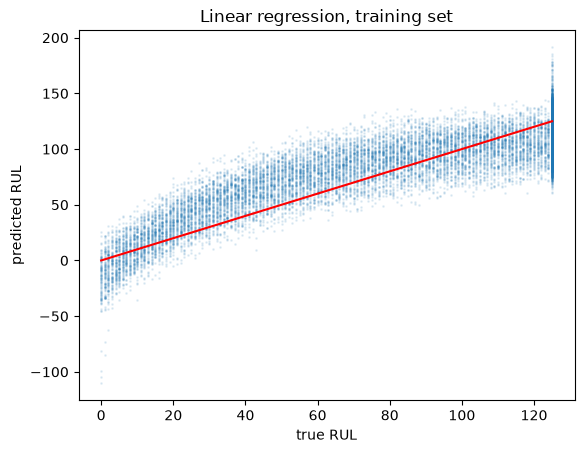

In [12]:
plt.scatter(y, model_lr45.predict(X45), alpha=0.1, s=1)
plt.plot([0, 125], [0, 125], color='red')   # y=x 参考线:落在线上=猜得全对
plt.xlabel('true RUL')
plt.ylabel('predicted RUL')
plt.title('Linear regression, training set')
plt.savefig('../figures/lr_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
model_rf = RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=20, random_state=42, n_jobs=-1)
model_rf.fit(X45, y)

pred_rf_train = model_rf.predict(X45)
pred_rf_test  = model_rf.predict(xt45)

rmse_rf_train = root_mean_squared_error(y, pred_rf_train)
rmse_rf_test  = root_mean_squared_error(rul_df['true_RUL'], pred_rf_test)
print(f"train {rmse_rf_train:.2f} / test {rmse_rf_test:.2f}")


train 14.78 / test 21.62


In [14]:
imp = pd.Series(model_rf.feature_importances_, index=X45.columns).sort_values(ascending=False)
print(imp.head(20))
print((imp < 0.001).sum())

sensor_3_rmean     0.629525
sensor_2_rmean     0.113660
sensor_9_rmean     0.057721
sensor_9           0.035984
sensor_4_rmean     0.031932
sensor_21_rmean    0.025807
sensor_15_rmean    0.015221
sensor_14_rmean    0.011521
sensor_17_rmean    0.011094
sensor_20_rmean    0.009011
sensor_9_rstd      0.006828
sensor_13_rstd     0.006746
sensor_14_rstd     0.006451
sensor_11_rmean    0.006335
sensor_11_rstd     0.003898
sensor_7_rstd      0.003655
sensor_13_rmean    0.003204
sensor_8_rstd      0.003117
sensor_12_rstd     0.001958
sensor_7_rmean     0.001806
dtype: float64
18


In [15]:
features_v3 = imp[imp >= 0.001].index.tolist()
print(len(features_v3))

X_v3  = df[features_v3]
xt_v3 = test_df.groupby('unit').tail(1)[features_v3]

model_rf27 = RandomForestRegressor(n_estimators=100, max_depth=8,
                                   min_samples_leaf=20, random_state=42, n_jobs=-1)
model_rf27.fit(X_v3, y)
pred_rf27 = model_rf27.predict(xt_v3)
print(root_mean_squared_error(rul_df['true_RUL'], pred_rf27))

27
21.756276077750446


将特征从 45 个裁减至 27 个，测试 RMSE 从 21.62 微增至 21.76（+0.6%）。低重要度特征确实携带少量信息，但绝大部分预测能力集中在少数滑动均值特征上；在需要控制推理成本或简化传感器部署的场景下，这个折衷是划算的。

In [16]:
print(f"LR  15 features : {rmse_lr:.2f}")
print(f"LR  45 features : {rmse_lr45:.2f}")
print(f"RF  45 features : {rmse_rf_test:.2f}")
print(f"RF  27 features : {root_mean_squared_error(rul_df['true_RUL'], pred_rf27):.2f}")

LR  15 features : 21.89
LR  45 features : 20.19
RF  45 features : 21.62
RF  27 features : 21.76


In [17]:
print(root_mean_squared_error(y, model_lr.predict(X15)))
print(root_mean_squared_error(y, model_lr45.predict(X45)))
print(root_mean_squared_error(y, model_rf27.predict(X_v3)))

21.468484055667577
20.27152777024233
14.824952252024806
